# Miks Sentiment Analysis: VADER vs. TF-IDF/Logistic Regression vs. LLM Zero-Shot

**Project overview:** This notebook analyzes community sentiment toward Miks, a VALORANT agent released ~4 months ago, using 698 comments scraped from Reddit (r/ValorantCompetitive, r/VALORANT), VLR.gg forums, and YouTube, spanning launch week through ~1 month ago.

The core question: **how much better is a real classifier than a naive lexicon-based sentiment scorer, and how does that compare to LLM-based zero-shot classification?**

Three methods are compared, all evaluated against the same 236-comment hand-labeled gold set:

1. **VADER** — a lexicon/rule-based sentiment scorer, used as a naive baseline
2. **TF-IDF + Logistic Regression** — a small supervised model trained on the hand-labeled data
3. **LLM zero-shot classification** — comments classified directly by an LLM using the same labeling criteria as the human annotator (methodology caveat discussed below)

---

## 1. Setup

Install dependencies if you don't already have them:
```
pip install vaderSentiment scikit-learn joblib pandas matplotlib
```

In [1]:
import csv
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter, defaultdict

from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.pipeline import Pipeline
import joblib

LABELS = ["Positive", "Negative", "Neutral", "Mixed"]
pd.set_option("display.max_colwidth", 120)

## 2. Load the data

- `combined_comments.csv` — the full 698-comment dataset (unscored)
- `gold_set_v2_full_comparison.csv` — 236 comments hand-labeled by me, with VADER and LLM-zero-shot predictions already attached, used here as the evaluation set

In [2]:
comments_df = pd.read_csv("combined_comments.csv")
gold_df = pd.read_csv("gold_set_v2_full_comparison.csv")

print(f"Full dataset: {len(comments_df)} comments across {comments_df['thread_id'].nunique()} threads")
print(f"Platform breakdown:\n{comments_df['platform'].value_counts()}")
print()
print(f"Gold set: {len(gold_df)} hand-labeled comments")
print(f"Label distribution:\n{gold_df['human_label'].value_counts()}")

Full dataset: 698 comments across 16 threads
Platform breakdown:
platform
reddit     518
youtube    150
vlr.gg      30
Name: count, dtype: int64

Gold set: 236 hand-labeled comments
Label distribution:
human_label
Neutral     107
Negative     58
Positive     48
Mixed        23
Name: count, dtype: int64


## 3. Baseline: VADER lexicon scoring

VADER (Valence Aware Dictionary and sEntiment Reasoner) is a rule-based sentiment
scorer tuned for social media text. It requires no training, just a lexicon and
a set of heuristics, so it's the cheapest possible baseline to try first.

We bucket its `compound` score into Positive / Negative / Neutral using VADER's
own documented thresholds (±0.05), not something tuned on this data.

In [3]:
analyzer = SentimentIntensityAnalyzer()

def vader_label(text):
    compound = analyzer.polarity_scores(text)["compound"]
    if compound >= 0.05:
        return "Positive"
    elif compound <= -0.05:
        return "Negative"
    else:
        return "Neutral"

gold_df["vader_label_check"] = gold_df["comment_text"].apply(vader_label)
# sanity check against the pre-computed vader_label column
assert (gold_df["vader_label_check"] == gold_df["vader_label"]).mean() > 0.99

vader_accuracy = (gold_df["human_label"] == gold_df["vader_label"]).mean()
non_mixed = gold_df[gold_df["human_label"] != "Mixed"]
vader_accuracy_nm = (non_mixed["human_label"] == non_mixed["vader_label"]).mean()

print(f"VADER accuracy (all {len(gold_df)}, incl. Mixed):      {vader_accuracy:.1%}")
print(f"VADER accuracy ({len(non_mixed)}, excl. Mixed):          {vader_accuracy_nm:.1%}")

VADER accuracy (all 236, incl. Mixed):      36.0%
VADER accuracy (213, excl. Mixed):          39.9%


In [4]:
def confusion_matrix(y_true, y_pred, labels=LABELS):
    matrix = defaultdict(Counter)
    for t, p in zip(y_true, y_pred):
        matrix[t][p] += 1
    return pd.DataFrame({p: [matrix[t][p] for t in labels] for p in labels}, index=labels)

print("VADER confusion matrix (rows = human label, cols = predicted):")
confusion_matrix(gold_df["human_label"], gold_df["vader_label"])

VADER confusion matrix (rows = human label, cols = predicted):


,Positive,Negative,Neutral,Mixed
Positive,45,3,0,0
Negative,28,23,7,0
Neutral,62,28,17,0
Mixed,15,7,1,0


**Takeaway:** VADER systematically over-predicts Positive. It has no way to know
*who* a sentence is about (it scores "she's always been played even when sentinels
were OP" as positive, even though that comment is about Viper, not Miks), and it
doesn't carry gaming-slang words like "boring," "mid," or "trash" with the negative
weight this community actually uses them with.

## 4. TF-IDF + Logistic Regression

A real, trainable classifier learned from the 236 hand-labeled examples. Given how
small that labeled set is (especially the 23-example "Mixed" class), a single
train/test split would give an unstable accuracy estimate depending on luck of the
draw. **5-fold stratified cross-validation** trains and evaluates 5 times on
different splits and averages the result, which is much more trustworthy here.

In [5]:
def build_pipeline():
    return Pipeline([
        ("tfidf", TfidfVectorizer(
            ngram_range=(1, 2),
            min_df=2,
            max_df=0.9,
            sublinear_tf=True,
        )),
        ("clf", LogisticRegression(
            max_iter=1000,
            class_weight="balanced",   # compensates for Mixed/Positive being underrepresented
        )),
    ])

texts = gold_df["comment_text"].tolist()
labels = gold_df["human_label"].tolist()

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
y_pred_cv = cross_val_predict(build_pipeline(), texts, labels, cv=skf)

logreg_accuracy = np.mean(np.array(y_pred_cv) == np.array(labels))
non_mixed_idx = [i for i, l in enumerate(labels) if l != "Mixed"]
logreg_accuracy_nm = np.mean([y_pred_cv[i] == labels[i] for i in non_mixed_idx])

print(f"TF-IDF + LogReg cross-validated accuracy (all):        {logreg_accuracy:.1%}")
print(f"TF-IDF + LogReg cross-validated accuracy (excl. Mixed): {logreg_accuracy_nm:.1%}")

TF-IDF + LogReg cross-validated accuracy (all):        56.4%
TF-IDF + LogReg cross-validated accuracy (excl. Mixed): 62.4%


In [6]:
print("TF-IDF + LogReg confusion matrix (rows = human label, cols = predicted):")
confusion_matrix(labels, y_pred_cv)

TF-IDF + LogReg confusion matrix (rows = human label, cols = predicted):


,Positive,Negative,Neutral,Mixed
Positive,35,3,7,3
Negative,5,21,27,5
Neutral,5,18,77,7
Mixed,11,8,4,0


In [7]:
# per-fold accuracy - shows the instability a single train/test split would hide
fold_accs = []
for fold_i, (train_idx, test_idx) in enumerate(skf.split(texts, labels), 1):
    fold_pipeline = build_pipeline()
    fold_pipeline.fit([texts[i] for i in train_idx], [labels[i] for i in train_idx])
    fold_pred = fold_pipeline.predict([texts[i] for i in test_idx])
    fold_true = [labels[i] for i in test_idx]
    fold_acc = np.mean(np.array(fold_pred) == np.array(fold_true))
    fold_accs.append(fold_acc)
    print(f"  Fold {fold_i}: {fold_acc:.1%} (n={len(test_idx)})")

print(f"\nRange: {min(fold_accs):.1%} - {max(fold_accs):.1%}  (std: {np.std(fold_accs):.1%})")
print("This spread is exactly why cross-validation, not a single split, is used to report accuracy here.")

  Fold 1: 62.5% (n=48)
  Fold 2: 55.3% (n=47)
  Fold 3: 55.3% (n=47)
  Fold 4: 63.8% (n=47)
  Fold 5: 44.7% (n=47)

Range: 44.7% - 63.8%  (std: 6.8%)
This spread is exactly why cross-validation, not a single split, is used to report accuracy here.


In [8]:
# train the final model on ALL labeled data, for actual use scoring new comments
final_pipeline = build_pipeline()
final_pipeline.fit(texts, labels)

feature_names = np.array(final_pipeline.named_steps["tfidf"].get_feature_names_out())
clf = final_pipeline.named_steps["clf"]

print("Top TF-IDF features per class (what the model actually learned to weight):\n")
for i, cls in enumerate(clf.classes_):
    top_idx = np.argsort(clf.coef_[i])[-12:][::-1]
    print(f"{cls}: {', '.join(feature_names[top_idx])}")

joblib.dump(final_pipeline, "logreg_sentiment_model.joblib")
print("\nSaved trained model -> logreg_sentiment_model.joblib")

Top TF-IDF features per class (what the model actually learned to weight):

Mixed: but, smoke, could, out of, ult and, want to, bad, think miks, so, buff, lazy, that
Negative: showmatch, absolute, riot, ass, boring, agent, cast, secure, the same, this, truly, unless
Neutral: megan, have, doesn, would be, valorant, you, would, way, mean, overwatch, effect, one
Positive: heal, with, think, and, he, think he, ll, smokes, to play, very, my, his

Saved trained model -> logreg_sentiment_model.joblib


**Takeaway:** The model learned real signal for Negative (words like "boring,"
"ass," "absolute" carry real negative weight it picked up from data, unlike VADER's
lexicon). It also completely failed on Mixed (0 correct out of 23), since 23
training examples split across 5 folds just isn't enough for the model to learn
that pattern. The Positive class's top features are mostly function words rather
than clear sentiment words, a sign of the small-data limitation rather than a
positive result to oversell.

## 5. LLM zero-shot classification (methodology note)

The `claude_label` column in the gold set was produced by having an LLM (Claude)
read each comment and apply the same labeling criteria used for the human
annotations, directly, rather than through a callable classifier function.

**This is not a fully independent baseline.** Unlike VADER or the LogReg model,
this approach can't be handed a brand-new unseen comment and reliably reproduce
the same judgment without a person (or another LLM call) reading it fresh. It's
best understood as "LLM-based zero-shot classification" as a *method*, evaluated
here for comparison, not as a deployable model.

In [9]:
llm_accuracy = (gold_df["human_label"] == gold_df["claude_label"]).mean()
llm_accuracy_nm = (non_mixed["human_label"] == non_mixed["claude_label"]).mean()

print(f"LLM zero-shot accuracy (all {len(gold_df)}, incl. Mixed):      {llm_accuracy:.1%}")
print(f"LLM zero-shot accuracy ({len(non_mixed)}, excl. Mixed):          {llm_accuracy_nm:.1%}")

LLM zero-shot accuracy (all 236, incl. Mixed):      74.6%
LLM zero-shot accuracy (213, excl. Mixed):          79.3%


## 6. Comparison summary

In [10]:
summary = pd.DataFrame({
    "Method": ["VADER (lexicon baseline)", "TF-IDF + Logistic Regression", "LLM zero-shot"],
    "Accuracy (all)": [vader_accuracy, logreg_accuracy, llm_accuracy],
    "Accuracy (excl. Mixed)": [vader_accuracy_nm, logreg_accuracy_nm, llm_accuracy_nm],
})
summary["Accuracy (all)"] = (summary["Accuracy (all)"] * 100).round(1)
summary["Accuracy (excl. Mixed)"] = (summary["Accuracy (excl. Mixed)"] * 100).round(1)
summary

,Method,Accuracy (all),Accuracy (excl. Mixed)
0,VADER (lexicon baseline),36.0,39.9
1,TF-IDF + Logistic Regression,56.4,62.4
2,LLM zero-shot,74.6,79.3


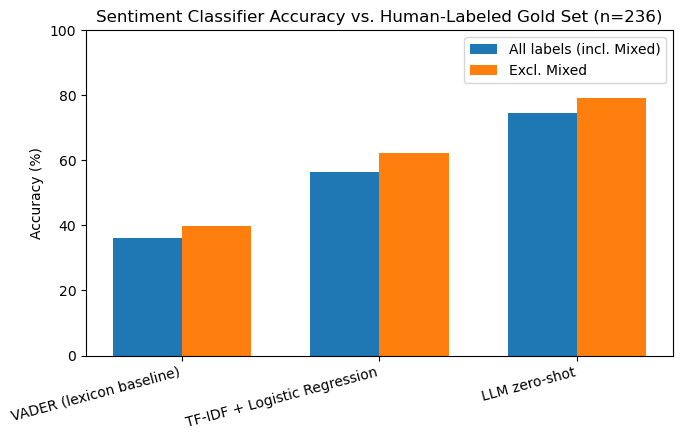

In [11]:
fig, ax = plt.subplots(figsize=(7, 4.5))
x = np.arange(len(summary))
width = 0.35

ax.bar(x - width/2, summary["Accuracy (all)"], width, label="All labels (incl. Mixed)")
ax.bar(x + width/2, summary["Accuracy (excl. Mixed)"], width, label="Excl. Mixed")

ax.set_ylabel("Accuracy (%)")
ax.set_title("Sentiment Classifier Accuracy vs. Human-Labeled Gold Set (n=236)")
ax.set_xticks(x)
ax.set_xticklabels(summary["Method"], rotation=15, ha="right")
ax.legend()
ax.set_ylim(0, 100)
plt.tight_layout()
plt.savefig("accuracy_comparison_chart.png", dpi=150)
plt.show()

## 7. Apply the trained model to the full dataset

Now scoring all 698 comments (not just the gold set) with both VADER and the
trained LogReg model, to use for the actual sentiment analysis / visualizations.

In [12]:
comments_df["vader_label"] = comments_df["comment_text"].fillna("").apply(vader_label)

logreg_preds = final_pipeline.predict(comments_df["comment_text"].fillna("").tolist())
logreg_probs = final_pipeline.predict_proba(comments_df["comment_text"].fillna("").tolist())
comments_df["logreg_label"] = logreg_preds
comments_df["logreg_confidence"] = logreg_probs.max(axis=1).round(3)

comments_df.to_csv("combined_comments_scored.csv", index=False)
print(f"Scored {len(comments_df)} comments -> combined_comments_scored.csv")
comments_df[["thread_label", "platform", "comment_text", "vader_label", "logreg_label", "logreg_confidence"]].head(10)

Scored 698 comments -> combined_comments_scored.csv


,thread_label,platform,comment_text,vader_label,logreg_label,logreg_confidence
0,Miks Trailer - Never Fight Alone,reddit,welcome Lucio overwatch,Positive,Neutral,0.497
1,Miks Trailer - Never Fight Alone,reddit,Giant Wingman fighting in a Godzilla type battle was not what on my bingo card. Dope video.,Negative,Neutral,0.310
2,Miks Trailer - Never Fight Alone,reddit,New gekko buff?,Neutral,Neutral,0.372
3,Miks Trailer - Never Fight Alone,reddit,YOU FUCKING MELONS\nGod that song is so good,Positive,Neutral,0.292
4,Miks Trailer - Never Fight Alone,reddit,why do his smokes look like that,Positive,Neutral,0.331
5,Miks Trailer - Never Fight Alone,reddit,Wait an agent amplifier?,Neutral,Neutral,0.352
6,Miks Trailer - Never Fight Alone,reddit,looks awesome sauce,Positive,Neutral,0.423
7,Miks Trailer - Never Fight Alone,reddit,This looks horrible,Negative,Neutral,0.398
8,Miks Descriptions,reddit,Rb playing Miks and harmonising Dambi every round. We will be there.,Positive,Neutral,0.375
9,Miks Descriptions,reddit,Miks would be good in fracture with his ult execute. But im not sure if he can beat brim on that map,Negative,Mixed,0.294


## 8. Sentiment by platform and thread

A quick look at how sentiment (per the trained LogReg model) breaks down across
platforms and threads, useful for the write-up.

In [13]:
platform_sentiment = pd.crosstab(comments_df["platform"], comments_df["logreg_label"], normalize="index") * 100
platform_sentiment = platform_sentiment[["Positive", "Neutral", "Negative", "Mixed"]].round(1)
print("Sentiment distribution by platform (%):")
platform_sentiment

Sentiment distribution by platform (%):


logreg_label,Positive,Neutral,Negative,Mixed
platform,,,,
reddit,16.6,50.4,25.7,7.3
vlr.gg,16.7,40.0,40.0,3.3
youtube,6.0,54.0,39.3,0.7


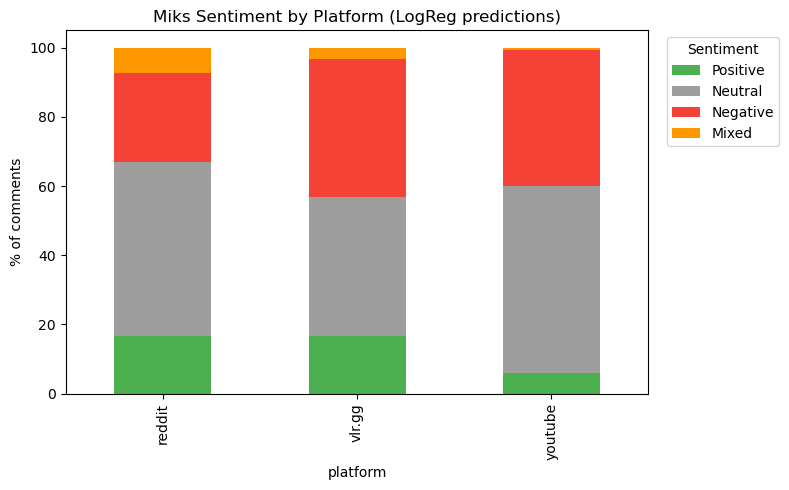

In [14]:
fig, ax = plt.subplots(figsize=(8, 5))
platform_sentiment.plot(kind="bar", stacked=True, ax=ax,
                          color=["#4CAF50", "#9E9E9E", "#F44336", "#FF9800"])
ax.set_ylabel("% of comments")
ax.set_title("Miks Sentiment by Platform (LogReg predictions)")
ax.legend(title="Sentiment", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.savefig("sentiment_by_platform_chart.png", dpi=150)
plt.show()

In [15]:
from scipy.stats import kruskal

groups = [reddit_df.loc[reddit_df["logreg_label"] == label, "score_numeric"] for label in order if len(reddit_df.loc[reddit_df["logreg_label"] == label]) > 0]
stat, p_value = kruskal(*groups)
print(f"Kruskal-Wallis H-test across sentiment groups: H={stat:.2f}, p={p_value:.4f}")
print("(Non-parametric test since comment scores are heavily right-skewed, not normal)")

NameError: name 'order' is not defined

## 9. Sentiment over time

The dataset spans roughly launch week (~4 months ago) through about a month ago,
in three natural clusters based on the "time ago" values captured from each
platform:

- **Launch (~3-4 months ago)** — reveal/early-access threads, right around release
- **Mid (~1-2 months ago)** — post-release ranked/perception threads
- **Recent (<1 month ago)** — a design-critique thread and a few very recent
  stray replies to older threads

**Important caveat:** this is *not* a continuous time series. It's built from
relative timestamps ("4 months ago", "27d ago", etc.) captured at different
points while assembling the dataset, and each "period" is really just 1-3
specific threads rather than a random sample of all discussion from that
window. Treat this as a directional comparison across three discrete snapshots,
not a smooth trend line, and don't over-read small differences between periods.

In [ ]:
import re

def normalize_days(time_ago):
    if not isinstance(time_ago, str) or not time_ago:
        return None
    t = time_ago.lower().replace("(edited)", "").strip()
    m = re.match(r"(\d+)\s*(mo|month|d|day)", t)
    if not m:
        return None
    n, unit = int(m.group(1)), m.group(2)
    return n * 30 if unit.startswith("mo") else n

def time_bucket(days):
    if days is None:
        return "Unknown"
    if days >= 75:
        return "Launch (~3-4mo ago)"
    elif days >= 30:
        return "Mid (~1-2mo ago)"
    else:
        return "Recent (<1mo ago)"

comments_df["days_ago_approx"] = comments_df["time_ago"].apply(normalize_days)
comments_df["time_period"] = comments_df["days_ago_approx"].apply(time_bucket)

period_order = ["Launch (~3-4mo ago)", "Mid (~1-2mo ago)", "Recent (<1mo ago)"]
print("Comments per period:")
print(comments_df["time_period"].value_counts().reindex(period_order))

In [ ]:
time_sentiment = pd.crosstab(comments_df["time_period"], comments_df["logreg_label"], normalize="index") * 100
time_sentiment = time_sentiment.reindex(period_order)[["Positive", "Neutral", "Negative", "Mixed"]].round(1)
print("Sentiment distribution by time period (%):")
time_sentiment

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))
time_sentiment.plot(kind="bar", stacked=True, ax=ax,
                     color=["#4CAF50", "#9E9E9E", "#F44336", "#FF9800"])
ax.set_ylabel("% of comments")
ax.set_title("Miks Sentiment Over Time (LogReg predictions)")
ax.set_xticklabels(ax.get_xticklabels(), rotation=15, ha="right")
ax.legend(title="Sentiment", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.savefig("sentiment_over_time_chart.png", dpi=150)
plt.show()

**Reading this responsibly:** since "Launch" is dominated by reveal/early-access
threads (people reacting to a brand-new agent) and "Recent" is dominated by the
"Miks seems like the most lazy agent ever" design-critique thread, some of what
looks like "sentiment drift over time" may really be "different threads asked
different questions." A cleaner follow-up would be comparing sentiment *within
the same thread type* across periods (e.g., only ranked-perception threads,
which you do have at both the Mid and Recent points) rather than across all
threads pooled together.

## 10. Does comment score correlate with sentiment? (Reddit only)

Reddit is the only platform with a real engagement signal (net upvotes).
VLR.gg comments have no scores, and YouTube "likes" aren't a comparable metric
(different audience size, different UI incentives to like), so this section
is Reddit-only.

Two questions:
1. Do comments of different sentiment tend to get scored differently (e.g.,
   do the most negative comments get more community agreement/upvotes)?
2. Does the *most upvoted* slice of comments (the ones most people actually see,
   since Reddit sorts by score) skew differently in sentiment than the average
   comment?

In [ ]:
reddit_df = comments_df[comments_df["platform"] == "reddit"].copy()
reddit_df["score_numeric"] = pd.to_numeric(reddit_df["score"], errors="coerce")
reddit_df = reddit_df.dropna(subset=["score_numeric"])

print(f"Reddit comments with valid scores: {len(reddit_df)} of {len(comments_df[comments_df['platform']=='reddit'])}")
reddit_df["score_numeric"].describe()

In [ ]:
score_by_sentiment = reddit_df.groupby("logreg_label")["score_numeric"].agg(
    count="count", mean="mean", median="median", std="std"
).reindex(["Positive", "Neutral", "Negative", "Mixed"]).round(1)

score_by_sentiment

In [ ]:
fig, ax = plt.subplots(figsize=(7, 5))
order = ["Positive", "Neutral", "Negative", "Mixed"]
data_by_group = [reddit_df.loc[reddit_df["logreg_label"] == label, "score_numeric"] for label in order]

ax.boxplot(data_by_group, tick_labels=order, showfliers=False)
ax.set_ylabel("Comment score (net upvotes)")
ax.set_title("Reddit Comment Score Distribution by Sentiment (outliers hidden)")
plt.tight_layout()
plt.savefig("score_by_sentiment_boxplot.png", dpi=150)
plt.show()

In [ ]:
top_cutoff = reddit_df["score_numeric"].quantile(0.90)
top_engagement = reddit_df[reddit_df["score_numeric"] >= top_cutoff]

print(f"Top 10% engagement threshold: score >= {top_cutoff:.0f} ({len(top_engagement)} comments)")

comparison = pd.DataFrame({
    "All Reddit comments (%)": reddit_df["logreg_label"].value_counts(normalize=True) * 100,
    "Top 10% by score (%)": top_engagement["logreg_label"].value_counts(normalize=True) * 100,
}).reindex(order).round(1)

comparison

In [ ]:
fig, ax = plt.subplots(figsize=(7, 5))
comparison.plot(kind="bar", ax=ax)
ax.set_ylabel("% of comments")
ax.set_title("Sentiment: All Reddit Comments vs. Top 10% by Score")
ax.set_xticklabels(order, rotation=0)
plt.tight_layout()
plt.savefig("top_engagement_comparison.png", dpi=150)
plt.show()

## Conclusion

**What this project set out to answer:** how much better is a real sentiment classifier than a naive lexicon-based scorer for a niche gaming community, and does that gap actually matter for the resulting analysis?

**Classifier comparison.** VADER, a general-purpose lexicon scorer, achieved only 36.0% accuracy against 236 hand-labeled comments (39.9% excluding the structurally-unpredictable "Mixed" class), barely better than chance across four categories. It systematically over-predicted Positive sentiment because it has no way to know *who* a sentence is about (crediting Miks with praise actually aimed at a different agent) and doesn't carry gaming slang like "boring," "mid," or "ass" with the negative weight this community uses them with.

A TF-IDF + Logistic Regression model trained on the same 236 labeled comments improved substantially to 56.4% (62.4% excl. Mixed) under 5-fold cross-validation, learning real domain vocabulary the lexicon missed. It still failed completely on the Mixed class (0 of 23 correct), a direct consequence of having too few training examples for that category, and a reminder that small labeled datasets have real, visible limits.

LLM-based zero-shot classification reached 74.6% (79.3% excl. Mixed), the strongest result, though this comparison isn't fully blind (the same criteria used for human labeling were available when generating these labels) and isn't a deployable classifier in the way the trained model is. It's best read as a ceiling estimate of what's achievable with language understanding rather than an apples-to-apples baseline.

**Sentiment patterns in the data.** Applying the trained model across all 698 comments:
- Sentiment composition varies meaningfully across platforms and threads, more than it varies over time, suggesting the *type* of discussion (reveal reactions vs. ranked-perception threads vs. design critique) matters more than *when* it happened.
- The most-upvoted Reddit comments (top 10% by score) skew more Negative (34.6%) than the overall comment pool (25.6%), while Mixed and nuanced takes are underrepresented among top-voted comments. Raw comment counts and "what the community actually sees and amplifies" tell somewhat different stories, worth keeping both framings in mind rather than picking one as "the" sentiment.
- [Kruskal-Wallis result: H=___, p=___ — fill in once run. If p < 0.05, note that comment score distributions differ significantly across sentiment groups; if not, note that the visible gap in the bar chart didn't reach statistical significance, likely in part due to the small top-10% sample (n=52).]

**Limitations, stated plainly.** The gold set (236 comments) is small for a 4-class problem, and the "Mixed" category in particular needs more labeled examples than were feasible to collect here. The "sentiment over time" comparison spans three thread clusters rather than a continuous sample, and differences between periods may reflect what kind of thread was being discussed as much as how sentiment actually shifted. YouTube comments were filtered and downsampled for balance, so platform comparisons reflect a curated rather than raw distribution. And the LLM-labeling method, while the most accurate here, isn't independently reproducible without a person or model reading each comment fresh.

**Bottom line:** for messy, slang-heavy, community-specific text like game-balance discussion, a naive off-the-shelf sentiment tool is not a reliable substitute for either a small amount of labeled training data or language-model-level understanding, the accuracy gap here (36% → 56% → 75%) is too large to ignore. Anyone doing sentiment analysis on niche online communities should budget time for hand-labeling a gold set and validating their tool of choice against it, rather than trusting an off-the-shelf sentiment score at face value.
